# TFM - Transfer Learning con ResNet18 para clasificación de defectos (NEU-DET)

Este notebook implementa un modelo de clasificación de imágenes con PyTorch usando transfer learning sobre ResNet18 para las 6 clases del dataset NEU-DET: `crazing`, `inclusion`, `patches`, `pitted_surface`, `rolled-in_scale` y `scratches`.

In [1]:
# ============================
# 1) Importaciones y configuración
# ============================
import copy
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_fscore_support
)
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# Fijamos semillas para mejorar la reproducibilidad de los experimentos.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# GPU si está disponible, en caso contrario CPU.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo en uso: {device}')

Dispositivo en uso: cuda


In [2]:
# ==========================================
# 2) Transformaciones y carga del dataset
# ==========================================
# Rutas relativas desde notebooks/ hacia los conjuntos preparados en 01_preparar_datos.
train_dir = Path('../data/clasificacion_full')
val_dir = Path('../data/val')
test_dir = Path('../data/test')

for required_dir in [train_dir, val_dir, test_dir]:
    if not required_dir.exists():
        raise FileNotFoundError(f'No existe la carpeta: {required_dir.resolve()}')

# Transformaciones de entrenamiento con data augmentation.
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transformaciones de validación (sin augmentation para evaluación objetiva).
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Dataset base (train) para extraer clases y configurar el modelo.
base_dataset = datasets.ImageFolder(root=train_dir)
class_names = base_dataset.classes
num_classes = len(class_names)

print(f'Número de clases: {num_classes}')
print(f'Clases detectadas: {class_names}')
print(f'Imágenes train: {len(datasets.ImageFolder(root=train_dir))}')
print(f'Imágenes val:   {len(datasets.ImageFolder(root=val_dir))}')
print(f'Imágenes test:  {len(datasets.ImageFolder(root=test_dir))}')

Número de clases: 6
Clases detectadas: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Imágenes train: 1439
Imágenes val:   180
Imágenes test:  180


In [3]:
# ==================================================
# 3) Carga de Train/Validation y DataLoaders
# ==================================================
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=val_transform)

# Validar que la codificación de clases sea consistente entre train y val.
if train_dataset.class_to_idx != val_dataset.class_to_idx:
    raise ValueError(
        f'Mapeo de clases distinto entre train y val. '
        f'train={train_dataset.class_to_idx}, val={val_dataset.class_to_idx}'
    )

batch_size = 32
num_workers = 0 

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available()
)

print(f'Muestras de entrenamiento: {len(train_dataset)}')
print(f'Muestras de validación: {len(val_dataset)}')

Muestras de entrenamiento: 1439
Muestras de validación: 180


In [4]:
# =========================================================
# 4) Definición del modelo ResNet18 con Transfer Learning
# =========================================================
def build_resnet18_transfer(num_classes=6):
    """
    Carga ResNet18 preentrenada en ImageNet y adapta la capa final
    para clasificación multiclase en NEU-DET.
    """
    if hasattr(models, 'ResNet18_Weights'):
        weights = models.ResNet18_Weights.DEFAULT
        model = models.resnet18(weights=weights)
    else:
        model = models.resnet18(pretrained=True)

    # Congelar inicialmente todo el backbone.
    for param in model.parameters():
        param.requires_grad = False

    # Descongelar la última etapa convolucional para un fine-tuning ligero.
    for param in model.layer4.parameters():
        param.requires_grad = True

    # Reemplazar la capa final para el número de clases objetivo.
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    # Asegurar que la nueva cabeza sea entrenable.
    for param in model.fc.parameters():
        param.requires_grad = True

    return model

model = build_resnet18_transfer(num_classes=num_classes).to(device)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [5]:
# =============================================
# 5) Función de pérdida, optimizador y scheduler
# =============================================
criterion = nn.CrossEntropyLoss()

# Optimizamos solo los parámetros entrenables (capa FC + layer4 descongelada).
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(trainable_params, lr=1e-4, weight_decay=1e-4)

# Reduce el learning rate cuando la pérdida de validación se estanca.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

print('Configuración de entrenamiento:')
print(f'- Loss: {criterion.__class__.__name__}')
print(f'- Optimizador: {optimizer.__class__.__name__}')
print('- Scheduler: ReduceLROnPlateau')

Configuración de entrenamiento:
- Loss: CrossEntropyLoss
- Optimizador: Adam
- Scheduler: ReduceLROnPlateau


In [6]:
# =========================================================
# 6) Funciones auxiliares para entrenar y validar por epoch
# =========================================================
def run_epoch(model, dataloader, criterion, optimizer=None, device='cpu'):
    """
    Ejecuta una época de entrenamiento o validación.
    Si 'optimizer' es None, realiza solo validación.
    Retorna loss, accuracy y métricas macro (precision, recall, f1).
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    running_corrects = 0
    total_samples = 0
    all_preds = []
    all_labels = []

    with torch.set_grad_enabled(is_train):
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if is_train:
                optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            preds = torch.argmax(outputs, dim=1)

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            running_corrects += (preds == labels).sum().item()
            total_samples += batch_size

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects / total_samples

    # Calcular métricas macro (precisión, recall, F1) por época.
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0
    )

    return epoch_loss, epoch_acc, precision_macro, recall_macro, f1_macro

In [7]:
# ==============================================
# 7) Bucle principal de entrenamiento con Early Stopping
# ==============================================
num_epochs = 100
patience = 10
patience_counter = 0

history = {
    'train_loss': [],
    'train_acc': [],
    'train_precision_macro': [],
    'train_recall_macro': [],
    'train_f1_macro': [],
    'val_loss': [],
    'val_acc': [],
    'val_precision_macro': [],
    'val_recall_macro': [],
    'val_f1_macro': [],
    'lr': []
}

best_val_acc = 0.0
best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):
    train_loss, train_acc, train_prec, train_rec, train_f1 = run_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_acc, val_prec, val_rec, val_f1 = run_epoch(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        optimizer=None,
        device=device
    )

    # Actualizamos scheduler en función de la pérdida de validación.
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_precision_macro'].append(train_prec)
    history['train_recall_macro'].append(train_rec)
    history['train_f1_macro'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_precision_macro'].append(val_prec)
    history['val_recall_macro'].append(val_rec)
    history['val_f1_macro'].append(val_f1)
    history['lr'].append(current_lr)

    # Guardamos el mejor estado según accuracy de validación.
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0  # Reiniciamos contador de paciencia.
    else:
        patience_counter += 1

    print(
        f'Epoch [{epoch + 1}/{num_epochs}] | '
        f'LR: {current_lr:.6f} | '
        f'Train [Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}] | '
        f'Val [Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}]'
    )

    # Early Stopping: si la pérdida de validación no mejora durante 'patience' epochs, paramos.
    if patience_counter >= patience:
        print(f'\nEarly Stopping activado en epoch {epoch + 1}/{num_epochs}.')
        break

# Restauramos el mejor modelo encontrado durante el entrenamiento.
model.load_state_dict(best_model_state)
print(f'Mejor Val Acc: {best_val_acc:.4f}')

Epoch [1/100] | LR: 0.000100 | Train [Loss: 0.3190, Acc: 0.9152, F1: 0.9160] | Val [Loss: 0.0732, Acc: 0.9833, F1: 0.9848]
Epoch [2/100] | LR: 0.000100 | Train [Loss: 0.0446, Acc: 0.9882, F1: 0.9881] | Val [Loss: 0.0126, Acc: 1.0000, F1: 1.0000]
Epoch [3/100] | LR: 0.000100 | Train [Loss: 0.0323, Acc: 0.9924, F1: 0.9922] | Val [Loss: 0.0101, Acc: 1.0000, F1: 1.0000]
Epoch [4/100] | LR: 0.000100 | Train [Loss: 0.0177, Acc: 0.9972, F1: 0.9972] | Val [Loss: 0.0074, Acc: 1.0000, F1: 1.0000]
Epoch [5/100] | LR: 0.000100 | Train [Loss: 0.0132, Acc: 0.9972, F1: 0.9972] | Val [Loss: 0.0040, Acc: 1.0000, F1: 1.0000]
Epoch [6/100] | LR: 0.000100 | Train [Loss: 0.0103, Acc: 0.9979, F1: 0.9979] | Val [Loss: 0.0238, Acc: 0.9889, F1: 0.9896]
Epoch [7/100] | LR: 0.000100 | Train [Loss: 0.0092, Acc: 0.9972, F1: 0.9972] | Val [Loss: 0.0163, Acc: 0.9944, F1: 0.9946]
Epoch [8/100] | LR: 0.000100 | Train [Loss: 0.0088, Acc: 0.9986, F1: 0.9986] | Val [Loss: 0.0205, Acc: 0.9944, F1: 0.9949]
Epoch [9/100] | 

In [8]:
# ==============================================
# 8) Guardado del mejor modelo entrenado
# ==============================================
output_model_path = Path('../src/resnet18_transfer_learning_best.pth')
output_model_path.parent.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        'model_state_dict': model.state_dict(),
        'class_names': class_names,
        'best_val_acc': best_val_acc,
        'history': history
    },
    output_model_path
)

print(f'Mejor modelo guardado en: {output_model_path.resolve()}')

Mejor modelo guardado en: C:\Users\Usuario\Desktop\TFM_CNN_Custom\src\resnet18_transfer_learning_best.pth


## Evaluación visual del entrenamiento

Las siguientes celdas permiten analizar el comportamiento del modelo mediante curvas de aprendizaje, evolución del learning rate y matriz de confusión sobre el conjunto de validación.

Gráfica guardada en: ..\resultados\resnet18_transfer_learning\curvas_aprendizaje.png


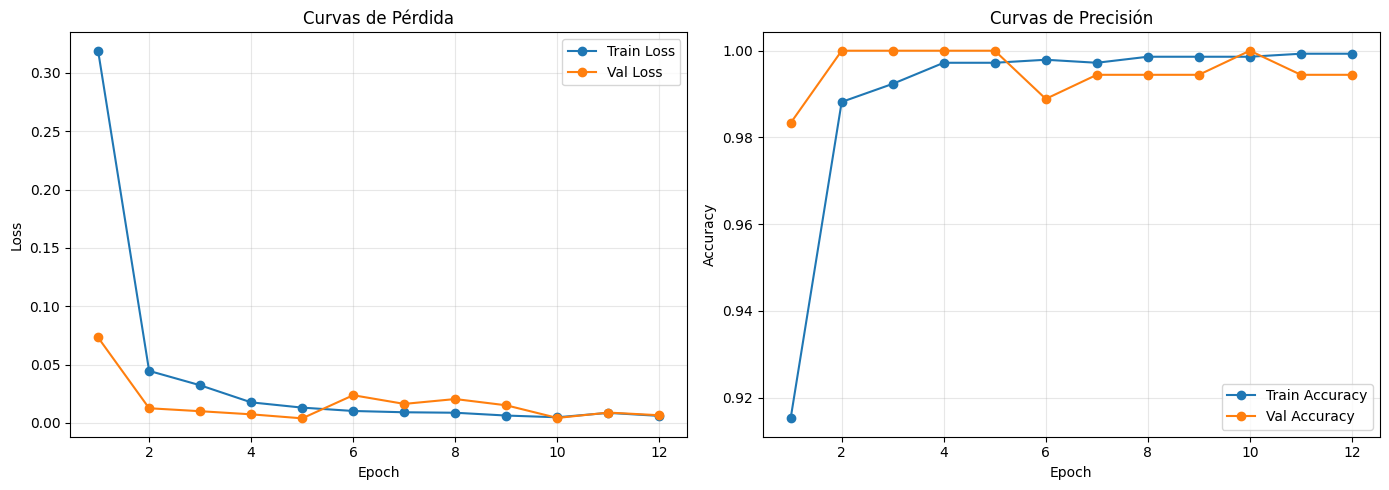

Gráfica guardada en: ..\resultados\resnet18_transfer_learning\evolucion_lr.png


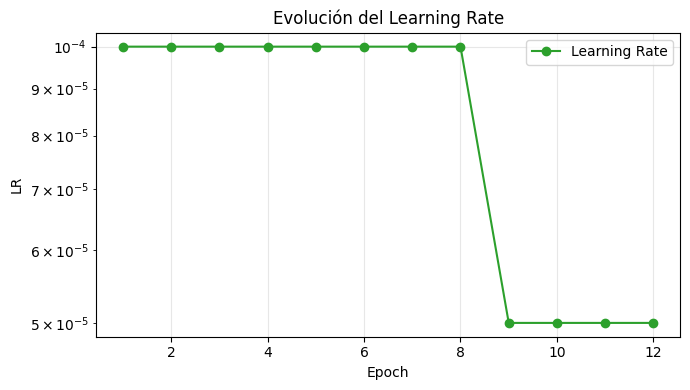

Gráfica guardada en: ..\resultados\resnet18_transfer_learning\metricas_macro.png


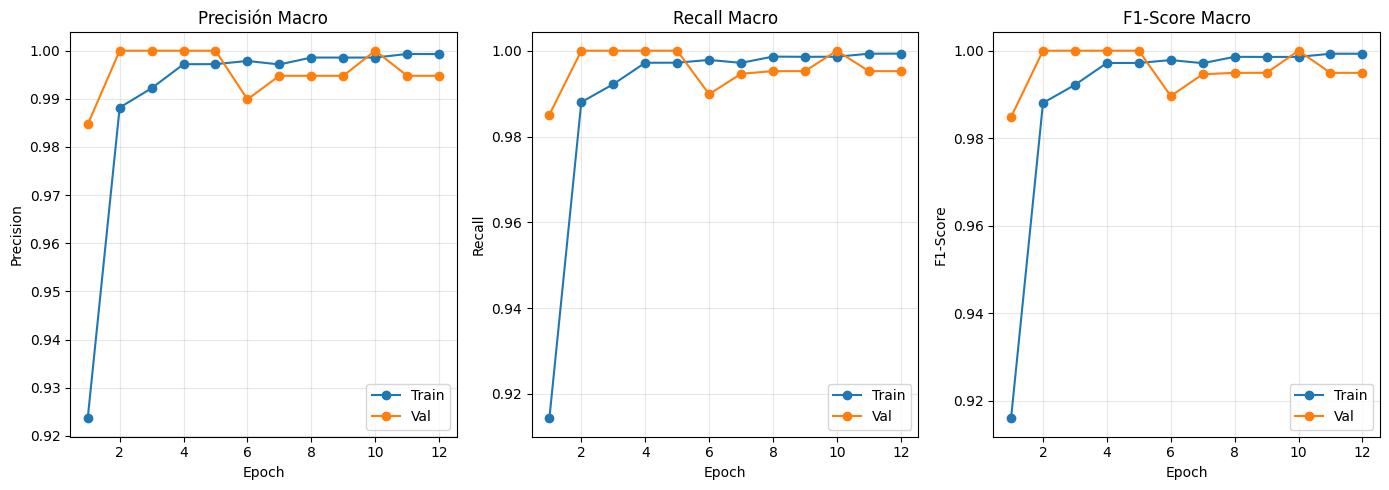

In [9]:
# ==============================================
# 9) Curvas de aprendizaje (Loss y Accuracy) con exportación
# ==============================================
# Crear directorio de resultados si no existe.
results_dir = Path('../resultados/resnet18_transfer_learning/')
results_dir.mkdir(parents=True, exist_ok=True)

# Solo usamos epochs hasta donde se detuvo el entrenamiento.
num_epochs_trained = len(history['train_loss'])
epochs = np.arange(1, num_epochs_trained + 1)

# Figura 1: Curvas de pérdida y precisión.
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], label='Train Loss', marker='o')
plt.plot(epochs, history['val_loss'], label='Val Loss', marker='o')
plt.title('Curvas de Pérdida')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history['train_acc'], label='Train Accuracy', marker='o')
plt.plot(epochs, history['val_acc'], label='Val Accuracy', marker='o')
plt.title('Curvas de Precisión')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
learning_curves_path = results_dir / 'curvas_aprendizaje.png'
plt.savefig(learning_curves_path, dpi=300, bbox_inches='tight')
print(f'Gráfica guardada en: {learning_curves_path}')
plt.show()

# Figura 2: Evolución del Learning Rate.
plt.figure(figsize=(7, 4))
plt.plot(epochs, history['lr'], label='Learning Rate', marker='o', color='tab:green')
plt.title('Evolución del Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
lr_path = results_dir / 'evolucion_lr.png'
plt.savefig(lr_path, dpi=300, bbox_inches='tight')
print(f'Gráfica guardada en: {lr_path}')
plt.show()

# Figura 3: Curvas de métricas macro (Precision, Recall, F1).
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs, history['train_precision_macro'], label='Train', marker='o')
plt.plot(epochs, history['val_precision_macro'], label='Val', marker='o')
plt.title('Precisión Macro')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs, history['train_recall_macro'], label='Train', marker='o')
plt.plot(epochs, history['val_recall_macro'], label='Val', marker='o')
plt.title('Recall Macro')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs, history['train_f1_macro'], label='Train', marker='o')
plt.plot(epochs, history['val_f1_macro'], label='Val', marker='o')
plt.title('F1-Score Macro')
plt.xlabel('Epoch')
plt.ylabel('F1-Score')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
metrics_path = results_dir / 'metricas_macro.png'
plt.savefig(metrics_path, dpi=300, bbox_inches='tight')
print(f'Gráfica guardada en: {metrics_path}')
plt.show()

Matriz de confusión guardada en: ..\resultados\resnet18_transfer_learning\matriz_confusion.png


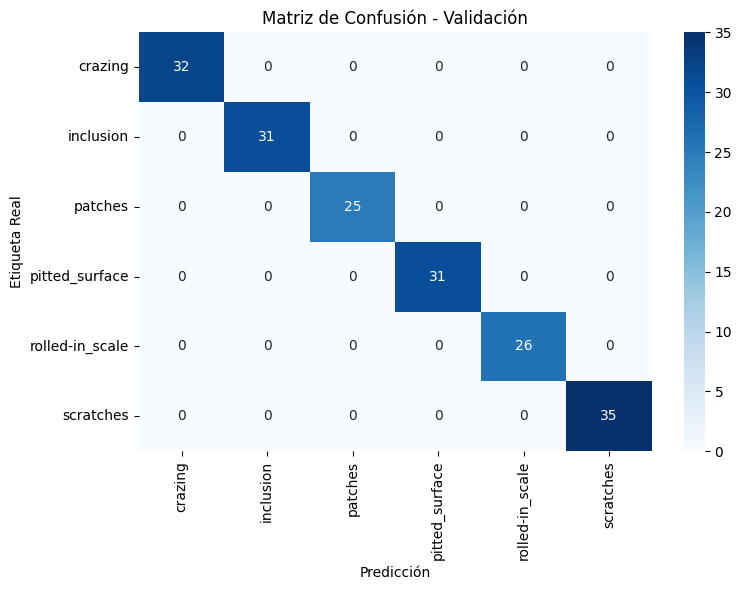

Reporte de clasificación (validación):
                 precision    recall  f1-score   support

        crazing     1.0000    1.0000    1.0000        32
      inclusion     1.0000    1.0000    1.0000        31
        patches     1.0000    1.0000    1.0000        25
 pitted_surface     1.0000    1.0000    1.0000        31
rolled-in_scale     1.0000    1.0000    1.0000        26
      scratches     1.0000    1.0000    1.0000        35

       accuracy                         1.0000       180
      macro avg     1.0000    1.0000    1.0000       180
   weighted avg     1.0000    1.0000    1.0000       180

Reporte guardado en: ..\resultados\resnet18_transfer_learning\reporte_clasificacion.txt


In [10]:
# ==============================================
# 10) Matriz de confusión y reporte de clasificación con exportación
# ==============================================
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Matriz de Confusión - Validación')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.tight_layout()
cm_path = results_dir / 'matriz_confusion.png'
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
print(f'Matriz de confusión guardada en: {cm_path}')
plt.show()

print('Reporte de clasificación (validación):')
report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print(report)

# Guardar reporte como texto en archivo.
report_path = results_dir / 'reporte_clasificacion.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report)
print(f'Reporte guardado en: {report_path}')

Cargando los mejores pesos desde: ..\src\resnet18_transfer_learning_best.pth
Resultados en TEST externo:
Accuracy:  1.0000
Precision macro: 1.0000
Recall macro:    1.0000
F1 macro:        1.0000
Matriz de confusión test guardada en: ..\resultados\resnet18_transfer_learning\evaluacion_test\matriz_confusion_test.png


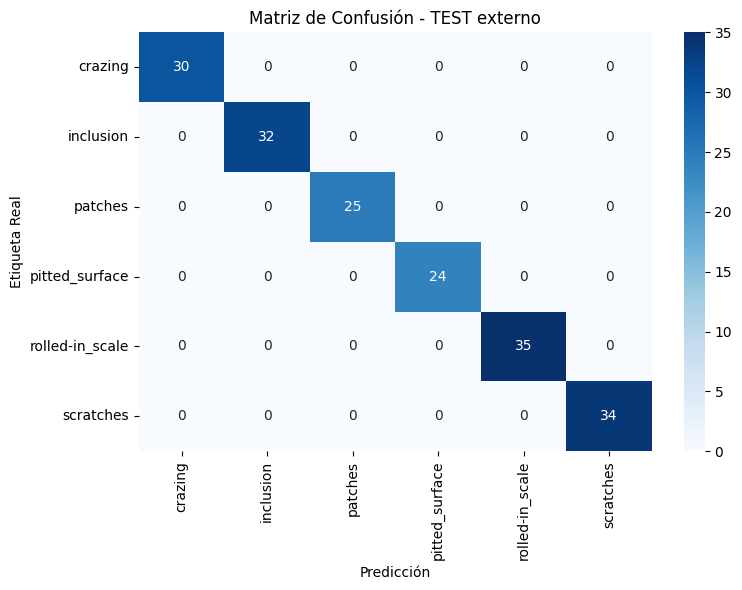

Reporte de clasificación (TEST):
                 precision    recall  f1-score   support

        crazing     1.0000    1.0000    1.0000        30
      inclusion     1.0000    1.0000    1.0000        32
        patches     1.0000    1.0000    1.0000        25
 pitted_surface     1.0000    1.0000    1.0000        24
rolled-in_scale     1.0000    1.0000    1.0000        35
      scratches     1.0000    1.0000    1.0000        34

       accuracy                         1.0000       180
      macro avg     1.0000    1.0000    1.0000       180
   weighted avg     1.0000    1.0000    1.0000       180

Reporte de test guardado en: ..\resultados\resnet18_transfer_learning\evaluacion_test\reporte_clasificacion_test.txt


In [11]:
# ==============================================
# 11) Evaluación final en set TEST externo (no usado en entrenamiento)
# ==============================================
from pathlib import Path
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
)

if 'results_dir' not in globals():
    results_dir = Path('../resultados/resnet18_transfer_learning/')
    results_dir.mkdir(parents=True, exist_ok=True)

test_dir = Path('../data/test')
if not test_dir.exists():
    raise FileNotFoundError(f'No existe la carpeta de test: {test_dir.resolve()}')

test_dataset = ImageFolder(root=str(test_dir), transform=val_transform)

# Validar que las clases del test coincidan con las clases del entrenamiento.
if set(test_dataset.classes) != set(class_names):
    raise ValueError(
        f'Clases distintas entre train y test. train={class_names}, test={test_dataset.classes}'
    )

train_class_to_idx = {name: i for i, name in enumerate(class_names)}
idx_map_test_to_train = {
    test_idx: train_class_to_idx[class_name]
    for class_name, test_idx in test_dataset.class_to_idx.items()
}

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
)

ruta_mejor_modelo = Path('../src/resnet18_transfer_learning_best.pth')

if ruta_mejor_modelo.exists():
    print(f'Cargando los mejores pesos desde: {ruta_mejor_modelo}')
    checkpoint = torch.load(ruta_mejor_modelo, map_location=device)

    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
else:
    print('ADVERTENCIA: No se encontró el archivo .pth guardado. Usando el modelo en memoria RAM.')

model.eval()
test_preds = []
test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        mapped_labels = [idx_map_test_to_train[int(l)] for l in labels.numpy()]

        test_preds.extend(preds)
        test_labels.extend(mapped_labels)

test_acc = accuracy_score(test_labels, test_preds)
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
    test_labels,
    test_preds,
    average='macro',
    zero_division=0,
)

print('Resultados en TEST externo:')
print(f'Accuracy:  {test_acc:.4f}')
print(f'Precision macro: {prec_macro:.4f}')
print(f'Recall macro:    {rec_macro:.4f}')
print(f'F1 macro:        {f1_macro:.4f}')

cm_test = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title('Matriz de Confusión - TEST externo')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.tight_layout()

test_results_dir = results_dir / 'evaluacion_test'
test_results_dir.mkdir(parents=True, exist_ok=True)

cm_test_path = test_results_dir / 'matriz_confusion_test.png'
plt.savefig(cm_test_path, dpi=300, bbox_inches='tight')
print(f'Matriz de confusión test guardada en: {cm_test_path}')
plt.show()

report_test = classification_report(
    test_labels,
    test_preds,
    target_names=class_names,
    digits=4,
)
print('Reporte de clasificación (TEST):')
print(report_test)

report_test_path = test_results_dir / 'reporte_clasificacion_test.txt'
with open(report_test_path, 'w', encoding='utf-8') as f:
    f.write(report_test)
print(f'Reporte de test guardado en: {report_test_path}')